In [1]:
# Cell 1: 导入库
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

In [2]:
# Cell 2: 定义模型（和之前一样）
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

In [3]:
# Cell 3: 加载模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net().to(device)
model.load_state_dict(torch.load('mnist_model.pth', map_location=device, weights_only=False))
model.eval()
print("模型加载成功")

模型加载成功


In [4]:
# Cell 4: 预处理函数
def preprocess_image(image_path):
    img = Image.open(image_path).convert('L')  # 转灰度
    img = img.resize((28, 28))                 # 缩放到28x28
    img = img.rotate(15)
    img_tensor = transforms.ToTensor()(img)
    img_tensor = transforms.Normalize((0.1307,), (0.3081,))(img_tensor)
    return img_tensor, img

预测结果: 9


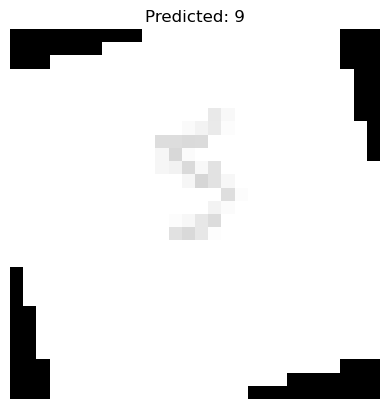

In [5]:
# Cell 5: 预测你的手写数字
image_path = "my_digit.png"  # 先准备好这张图
img_tensor, original_img = preprocess_image(image_path)

with torch.no_grad():
    img_tensor = img_tensor.unsqueeze(0).to(device)
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)

print(f"预测结果: {predicted[0].item()}")

# 显示你的图片
plt.imshow(original_img, cmap='gray')
plt.title(f"Predicted: {predicted[0].item()}")
plt.axis('off')
plt.show()

In [6]:
# Cell 6: 导出 ONNX
import torch.onnx

# 创建一个 dummy input（形状和真实输入一样）
dummy_input = torch.randn(1, 1, 28, 28).to(device)

# 导出
torch.onnx.export(
    model,
    dummy_input,
    "mnist_model.onnx",
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

print("ONNX 模型已保存为 mnist_model.onnx")

ONNX 模型已保存为 mnist_model.onnx


## 基础理解（应该能立即回答）
### 为什么模型在测试集上准确率很高（97%+），但识别你自己手写的数字时可能出错？
- 我感觉是因为训练中并没有以我的书写习惯为例子的样本，所以说错误率会相对更高。在我上边的例子中，我写了5，而5本身就比较容易被误判成6或者8.
- 补充一点：MNIST 的数字是居中的、平滑的、粗细均匀的，而画图写的数字可能偏左/偏右、粗细不均、边缘锯齿，这些都是模型没见过的。
### model.eval() 和 torch.no_grad() 的区别是什么？哪个是必须写的？
- model.eval()是让模型进入测试模式，而torch.no_grad()是让模型不要计算gradient。我认为model.eval()是必写的，因为这样模型的参数就会固定不变了。gradient就算被计算出来，除了会影响模型的速度以外没有大的问题。
- model.eval() 必须写（否则结果不对），torch.no_grad() 建议写（但不是必须，只是优化）
- model.eval()	作用是关闭 Dropout 和 BatchNorm 的训练行为	不写会导致预测结果随机（因为 Dropout 还在随机丢弃）
- torch.no_grad()作用是不计算梯度，节省显存和速度不写会导致结果仍然正确，但更慢、更耗显存
### 如果预处理时忘记写 transforms.Normalize((0.1307,), (0.3081,))，会发生什么？
- 如果预处理时没有normalize，那么模型计算的结果会有很大误差。
- 因为模型训练时看到的输入是 (0.1307, 0.3081) 归一化后的数据，如果你不归一化，输入的范围是 0-1，模型会“看不懂”，输出基本是错的。
## 动手验证（需要运行代码或改参数）
### 把你的手写数字图片旋转 15 度或向左偏移 5 个像素，预测结果会变吗？为什么？
- 理论上有可能，但是如果模型在好的训练集上训练的话，应该会覆盖这几种情景。
- MNIST 数据集本身没有做数据增强（旋转、偏移），所以模型对这些变化很敏感。你可以实际试一下：用 PIL 的 .rotate(15) 或 .crop() 改一下，看看预测会不会变。
### 把 chunk_size=30 改成 chunk_size=100，导出的 ONNX 文件大小会变吗？为什么？
- 我认为会变大，因为axes的大小会发生变化。
- 错误。chunk_size 是文本分块的参数（用于 RAG），和 ONNX 模型完全无关。ONNX 文件大小只取决于模型结构（网络层数、参数数量）。你改 chunk_size 只影响RecursiveCharacterTextSplitter 的行为。
## 深入思考（面试可能会问）
### 如果你想用这个模型识别彩色图片（比如 3 通道的 RGB 图片），需要做什么修改？
- 需要调整tensor的形状和维度。
- 把 nn.Conv2d(1, 32, ...) 改成 nn.Conv2d(3, 32, ...)（第一层输入通道从 1 改成 3），或者把彩色图片转成灰度图（convert('L')，你已经做了）
### ONNX 格式相比 PyTorch 的 .pth 格式有什么优势？什么场景下不适合用 ONNX？
- onnx更通用一些。
- 优势	说明
跨框架	PyTorch → ONNX → TensorFlow/TRT/OpenVINO 都可以
跨平台	可在不同硬件（CPU/GPU/NPU）上运行
推理加速	可配合 TensorRT 等工具做优化
不适用场景	说明
训练	ONNX 不支持反向传播，只能推理
动态控制流	如果模型有 if 或 while 依赖数据，导出困难
自定义层	需要额外注册，不能直接导出